In [81]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
import marimo as mo

from pathlib import Path

sys.path.insert(0, os.path.abspath("C:\\Users\\rhanes\\GitHub\\tyche\\src"))

import tyche as ty

In [62]:
start_year_atb = 2010
end_year_atb = 2060
start_year_timeseries = 2022

In [17]:
designs = ty.Designs(
    path = '.',
    name = 'small-modular-reactor.xlsx'
)
investments = ty.Investments(
    path = '.',
    name = 'small-modular-reactor.xlsx'
)

designs.compile()

In [18]:
tranche_results = investments.evaluate_tranches(designs, sample_count=100).metrics
#tranche_results.xs(1, level="Sample", drop_level=False)

Evaluating Nuclear SMR


[Text(0, 0, 'FOAK 6 Orders'),
 Text(1, 0, 'BOAK 2 of 6 Orders'),
 Text(2, 0, 'BOAK 3 of 6 Orders'),
 Text(3, 0, 'BOAK 4 of 6 Orders'),
 Text(4, 0, 'BOAK 5 of 6 Orders'),
 Text(5, 0, 'NOAK 6 Orders')]

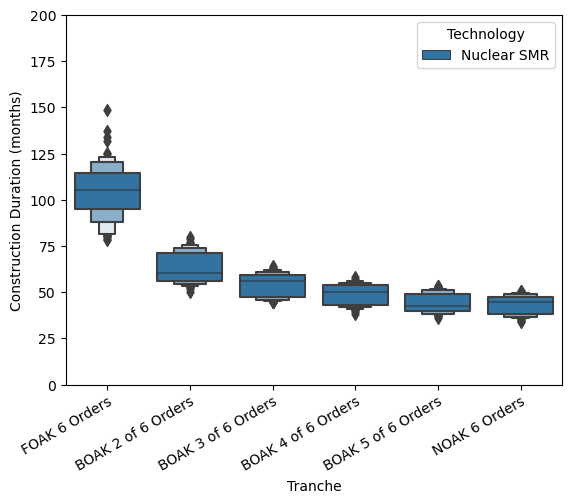

In [19]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Construction Duration",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK 6 Orders",
        "BOAK 2 of 6 Orders",
        "BOAK 3 of 6 Orders",
        "BOAK 4 of 6 Orders",
        "BOAK 5 of 6 Orders",
        "NOAK 6 Orders",
        ]
    )
g.set(ylabel="Construction Duration (months)",
     ylim=(0,200))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

[Text(0, 0, 'FOAK 6 Orders'),
 Text(1, 0, 'BOAK 2 of 6 Orders'),
 Text(2, 0, 'BOAK 3 of 6 Orders'),
 Text(3, 0, 'BOAK 4 of 6 Orders'),
 Text(4, 0, 'BOAK 5 of 6 Orders'),
 Text(5, 0, 'NOAK 6 Orders')]

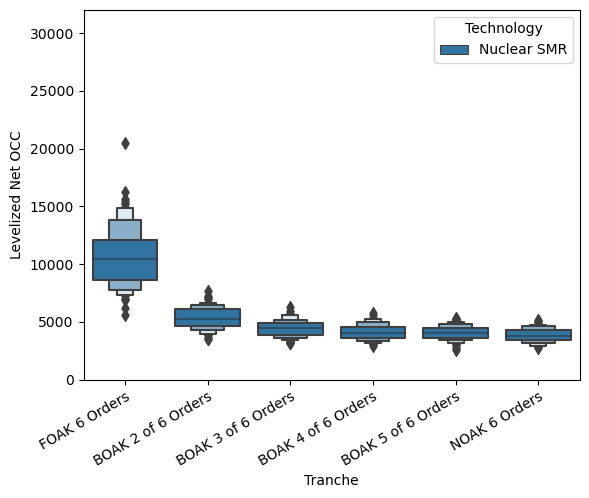

In [20]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Levelized Net OCC",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK 6 Orders",
        "BOAK 2 of 6 Orders",
        "BOAK 3 of 6 Orders",
        "BOAK 4 of 6 Orders",
        "BOAK 5 of 6 Orders",
        "NOAK 6 Orders",
        ]
    )
g.set(ylabel="Levelized Net OCC",
     ylim=(0,32000))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

[Text(0, 0, 'FOAK 3 Orders'),
 Text(1, 0, 'BOAK 3 Orders'),
 Text(2, 0, 'NOAK 3 Orders'),
 Text(3, 0, 'FOAK 6 Orders'),
 Text(4, 0, 'BOAK 6 Orders'),
 Text(5, 0, 'NOAK 6 Orders'),
 Text(6, 0, 'FOAK 13 Orders'),
 Text(7, 0, 'BOAK 13 Orders'),
 Text(8, 0, 'NOAK 13 Orders')]

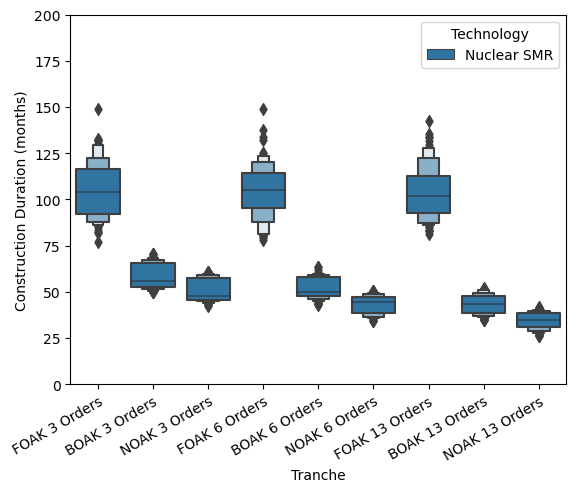

In [21]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Construction Duration",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK 3 Orders",
        "BOAK 3 Orders",
        "NOAK 3 Orders",
        "FOAK 6 Orders",
        "BOAK 6 Orders",
        "NOAK 6 Orders",
        "FOAK 13 Orders",
        "BOAK 13 Orders",
        "NOAK 13 Orders"
        ]
    )
g.set(ylabel="Construction Duration (months)",
     ylim=(0,200))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

[Text(0, 0, 'FOAK 3 Orders'),
 Text(1, 0, 'BOAK 3 Orders'),
 Text(2, 0, 'NOAK 3 Orders'),
 Text(3, 0, 'FOAK 6 Orders'),
 Text(4, 0, 'BOAK 6 Orders'),
 Text(5, 0, 'NOAK 6 Orders'),
 Text(6, 0, 'FOAK 13 Orders'),
 Text(7, 0, 'BOAK 13 Orders'),
 Text(8, 0, 'NOAK 13 Orders')]

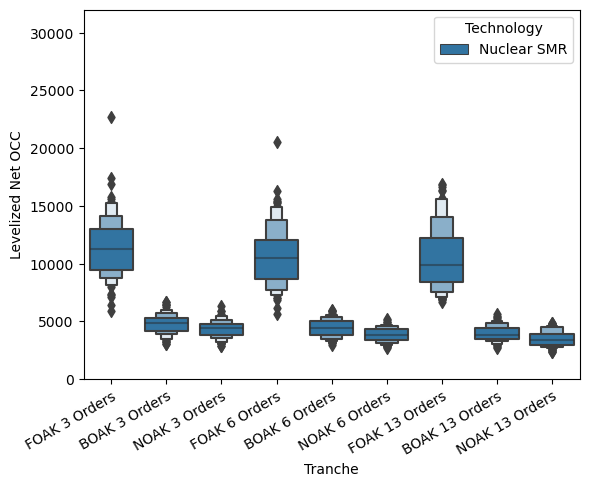

In [22]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Levelized Net OCC",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK 3 Orders",
        "BOAK 3 Orders",
        "NOAK 3 Orders",
        "FOAK 6 Orders",
        "BOAK 6 Orders",
        "NOAK 6 Orders",
        "FOAK 13 Orders",
        "BOAK 13 Orders",
        "NOAK 13 Orders"
        ]
    )
g.set(ylabel="Levelized Net OCC",
     ylim=(0,32000))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

In [70]:
tranches_timeseries = tranche_results.reset_index()

tranches_timeseries.drop(
    columns = ['Category','Technology','Units'],
    inplace = True
)

tranches_timeseries.rename(
    columns = {'Sample': 'sampl'},
    inplace = True
)

tranches_timeseries = tranches_timeseries[tranches_timeseries.Tranche.isin([
        "FOAK 6 Orders",
        "BOAK 2 of 6 Orders",
        "BOAK 3 of 6 Orders",
        "BOAK 4 of 6 Orders",
        "BOAK 5 of 6 Orders",
        "NOAK 6 Orders"
])]

tranches_timeseries = tranches_timeseries[tranches_timeseries.Index.isin([
    "Construction Duration",
    "Fixed Op and Maint",
    "Variable Op and Maint",
    "Levelized Net OCC"
])]

tranches_timeseries['plant'] = 1
tranches_timeseries.loc[tranches_timeseries.Tranche == 'BOAK 2 of 6 Orders','plant'] = 2
tranches_timeseries.loc[tranches_timeseries.Tranche == 'BOAK 3 of 6 Orders','plant'] = 3
tranches_timeseries.loc[tranches_timeseries.Tranche == 'BOAK 4 of 6 Orders','plant'] = 4
tranches_timeseries.loc[tranches_timeseries.Tranche == 'BOAK 5 of 6 Orders','plant'] = 5
tranches_timeseries.loc[tranches_timeseries.Tranche == 'NOAK 6 Orders','plant'] = 6

tranches_timeseries_occ = tranches_timeseries.loc[tranches_timeseries.Index == 'Levelized Net OCC', ['sampl','Value','plant']]
tranches_timeseries_duration = tranches_timeseries.loc[tranches_timeseries.Index == 'Construction Duration', ['sampl','Value','plant']]
tranches_timeseries_fom = tranches_timeseries.loc[tranches_timeseries.Index == 'Fixed Op and Maint', ['sampl','Value','plant']]
tranches_timeseries_vom = tranches_timeseries.loc[tranches_timeseries.Index == 'Variable Op and Maint', ['sampl','Value','plant']]

tranches_atb = tranches_timeseries_occ.merge(tranches_timeseries_duration,
                                             on = ['sampl','plant'],
                                             suffixes=('_occ', '_cons')
                                            ).merge(tranches_timeseries_fom,
                                                    on = ['sampl','plant']
                                                   ).merge(tranches_timeseries_vom,
                                                           on = ['sampl','plant'],
                                                           suffixes = ('_fom','_vom'))

tranches_atb.rename(
    columns = {'Value_occ': 'capcost',
              'Value_cons': 'cons_months',
              'Value_fom': 'fom',
              'Value_vom': 'vom'},
    inplace = True
)

tranches_atb['cons_years'] = np.ceil(tranches_atb.cons_months / 12)

tranches_atb['start_year'] = 0
tranches_atb['end_year'] = 0

tranches_atb.loc[tranches_atb.plant == 1, 'start_year'] = start_year_atb
tranches_atb.loc[tranches_atb.plant == 1, 'cons_years'] = (start_year_timeseries - start_year_atb) + tranches_atb.loc[tranches_atb.plant == 1, 'cons_years']
tranches_atb.loc[tranches_atb.plant == 1, 'end_year'] = start_year_atb + tranches_atb.loc[tranches_atb.plant == 1, 'cons_years']

for _s in tranches_atb.sampl.sort_values().unique():
    for _p in tranches_atb.plant.sort_values().unique():

        tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p), 'end_year'] = \
            tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p), 'start_year'].values[0] + \
            tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p), 'cons_years'].values[0] - 1
        
        if _p < tranches_atb.plant.max():
            tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p + 1), 'start_year'] = \
            tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p), 'end_year'].values[0] + 1

        if _p == tranches_atb.plant.max():
            tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p), 'end_year'] = end_year_atb + 1


# Sort first by sampl, then by plant number within sampl
tranches_atb = tranches_atb.sort_values(by = ['sampl','plant'])

tranches_atb['years'] = [np.arange(styr, enyr) for styr, enyr in zip(tranches_atb.start_year, tranches_atb.end_year)]

tranches_atb_timeseries = tranches_atb.explode(column = 'years')

tranches_atb_timeseries.to_csv('tranches-atb-withyears.csv',index=False)

In [71]:
tranches_atb_timeseries.loc[tranches_atb.sampl == 10]

,sampl,capcost,plant,cons_months,fom,vom,cons_years,start_year,end_year,years
409,10,9129.507571,1,85.988366,199.311826,11.586195,20.0,2010,2029,2010
409,10,9129.507571,1,85.988366,199.311826,11.586195,20.0,2010,2029,2011
409,10,9129.507571,1,85.988366,199.311826,11.586195,20.0,2010,2029,2012
409,10,9129.507571,1,85.988366,199.311826,11.586195,20.0,2010,2029,2013
409,10,9129.507571,1,85.988366,199.311826,11.586195,20.0,2010,2029,2014
409,10,9129.507571,1,85.988366,199.311826,11.586195,20.0,2010,2029,2015
409,10,9129.507571,1,85.988366,199.311826,11.586195,20.0,2010,2029,2016
409,10,9129.507571,1,85.988366,199.311826,11.586195,20.0,2010,2029,2017
409,10,9129.507571,1,85.988366,199.311826,11.586195,20.0,2010,2029,2018
409,10,9129.507571,1,85.988366,199.311826,11.586195,20.0,2010,2029,2019


In [25]:
smr_atb_mod = pd.read_csv('nuclear-smr_ATB_2025_moderate.csv')

In [79]:
tranches_atb_timeseries.years % 2

400    0
400    1
400    0
400    1
400    0
      ..
599    0
599    1
599    0
599    1
599    0
Name: years, Length: 4600, dtype: object

<AxesSubplot: xlabel='years', ylabel='capcost'>

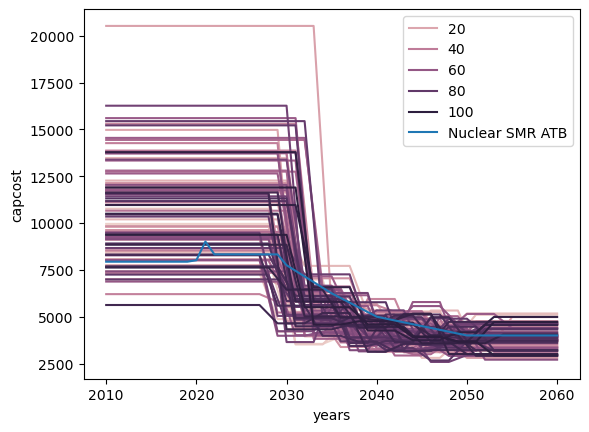

In [92]:
sb.lineplot(
    data = tranches_atb_timeseries,
    x = 'years',
    y = 'capcost',
    hue = 'sampl'
)

sb.lineplot(data = smr_atb_mod,
            x = 't',
            y = 'capcost',
            label = 'Nuclear SMR ATB'
           )

<AxesSubplot: xlabel='years', ylabel='capcost'>

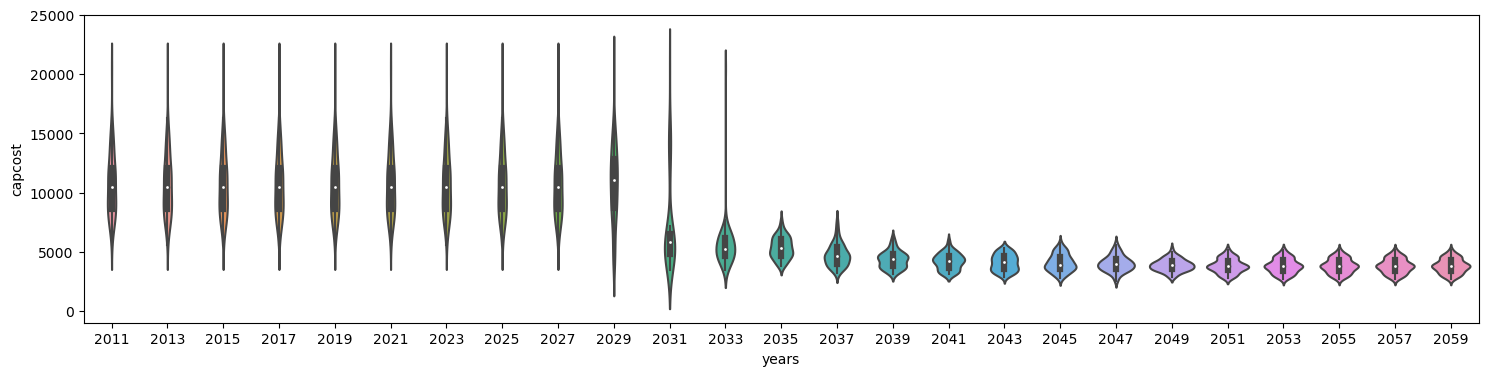

In [94]:
plt.figure(figsize=(18,4))

sb.violinplot(
    data = tranches_atb_timeseries.loc[tranches_atb_timeseries.years % 2 == 1],
    x = 'years',
    y = 'capcost',
    hue = None,
)

<AxesSubplot: xlabel='years', ylabel='fom'>

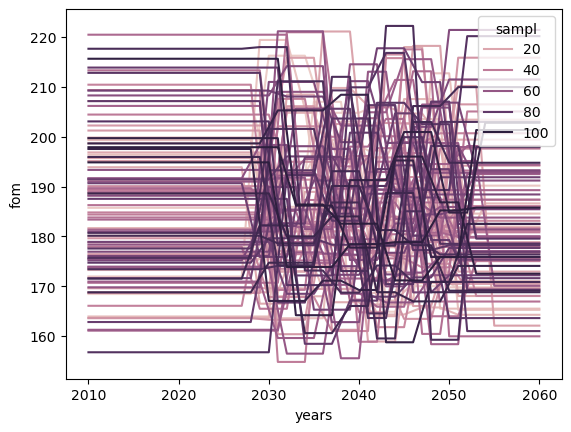

In [95]:
sb.lineplot(
    data = tranches_atb_timeseries,
    x = 'years',
    y = 'fom',
    hue = 'sampl'
)

#sb.lineplot(data = smr_atb_mod,
#            x = 't',
#            y = 'fom',
#            label = 'Nuclear SMR ATB'
#           )

<AxesSubplot: xlabel='years', ylabel='vom'>

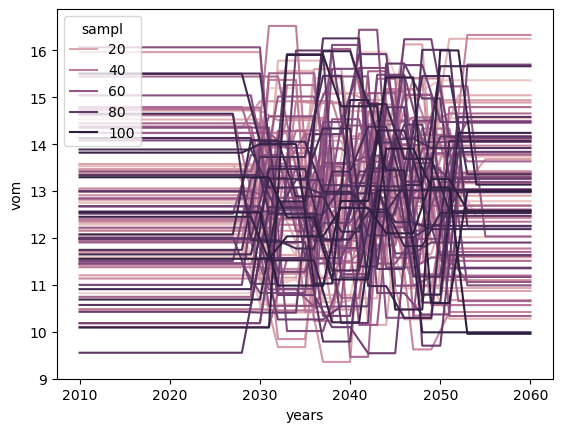

In [96]:
sb.lineplot(
    data = tranches_atb_timeseries,
    x = 'years',
    y = 'vom',
    hue = 'sampl'
)

#sb.lineplot(data = smr_atb_mod,
#            x = 't',
#            y = 'vom',
#            label = 'Nuclear SMR ATB'
#           )

<AxesSubplot: xlabel='years', ylabel='cons_years'>

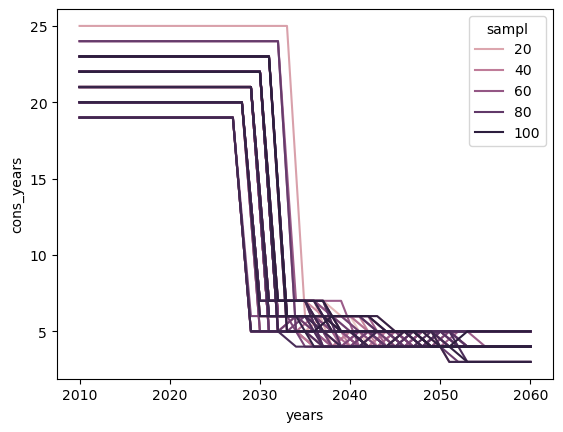

In [97]:
sb.lineplot(
    data = tranches_atb_timeseries,
    x = 'years',
    y = 'cons_years',
    hue = 'sampl'
)

In [98]:
tranches_atb_timeseries.head()

,sampl,capcost,plant,cons_months,fom,vom,cons_years,start_year,end_year,years
400,1,9164.747875,1,106.253635,177.927539,10.821327,21.0,2010,2030,2010
400,1,9164.747875,1,106.253635,177.927539,10.821327,21.0,2010,2030,2011
400,1,9164.747875,1,106.253635,177.927539,10.821327,21.0,2010,2030,2012
400,1,9164.747875,1,106.253635,177.927539,10.821327,21.0,2010,2030,2013
400,1,9164.747875,1,106.253635,177.927539,10.821327,21.0,2010,2030,2014


In [104]:
tranches_atb_timeseries_median = tranches_atb_timeseries.groupby('years').agg({'fom':'median','vom':'median','capcost':'median'}).reset_index()
tranches_atb_timeseries_median.to_csv('nuclear-smr-atb-median.csv',index=False)

In [105]:
tranches_atb_timeseries_min = tranches_atb_timeseries.groupby('years').agg({'fom':'min','vom':'min','capcost':'min'}).reset_index()
tranches_atb_timeseries_min.to_csv('nuclear-smr-atb-min.csv',index=False)

In [107]:
tranches_atb_timeseries_max = tranches_atb_timeseries.groupby('years').agg({'fom':'max','vom':'max','capcost':'max'}).reset_index()
tranches_atb_timeseries_max.to_csv('nuclear-smr-atb-max.csv',index=False)